In [4]:
import os

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

In [5]:
DATASET_PATH = "/workspaces/plant_disease_detection/data/raw"

In [6]:
classes = os.listdir(DATASET_PATH)

image_sizes = []

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    image_sizes.append(img.size)


sample_class = classes[0]

sample_folder = os.path.join(
    DATASET_PATH,
    sample_class
)

sample_image = os.listdir(sample_folder)[0]

sample_path = os.path.join(
    sample_folder,
    sample_image
)

img = Image.open(sample_path)

print(type(img))

<class 'PIL.JpegImagePlugin.JpegImageFile'>


In [7]:
print(image_sizes[:10])

[(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


In [8]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

In [9]:
sample_class = classes[0]

sample_folder = os.path.join(
    DATASET_PATH,
    sample_class
)

sample_image = os.listdir(sample_folder)[0]

sample_path = os.path.join(
    sample_folder,
    sample_image
)

img = Image.open(sample_path)

print(type(img))

<class 'PIL.JpegImagePlugin.JpegImageFile'>


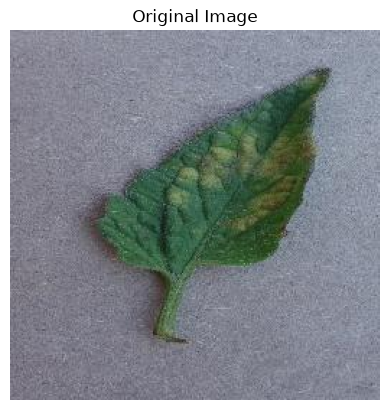

In [10]:
plt.imshow(img)

plt.title("Original Image")

plt.axis("off")

plt.show()

In [11]:
resized_img = img.resize((IMG_WIDTH, IMG_HEIGHT))

In [12]:
print(resized_img.size)

(224, 224)


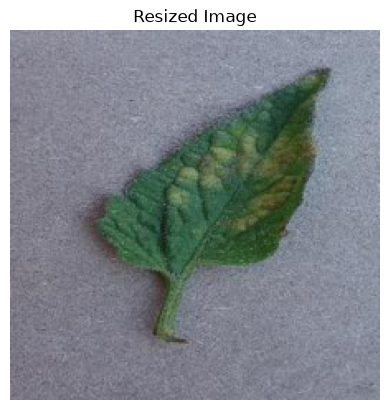

In [13]:
plt.imshow(resized_img)

plt.title("Resized Image")

plt.axis("off")

plt.show()

In [14]:
image_array = np.array(resized_img)

In [15]:
print(image_array.shape)

(224, 224, 3)


In [16]:
print(image_array.min())
print(image_array.max())

7
201


In [17]:
normalized_image = image_array / 255.0

In [18]:
print(normalized_image.min())
print(normalized_image.max())

0.027450980392156862
0.788235294117647


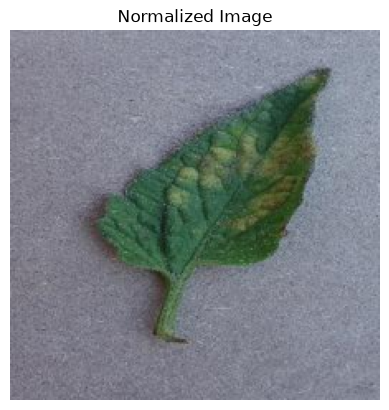

In [19]:
plt.imshow(normalized_image)

plt.title("Normalized Image")

plt.axis("off")

plt.show()

In [20]:
def preprocess_image(image_path):
    """
    Reads, resizes and normalizes an image.
    """

    img = Image.open(image_path)

    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    img = np.array(img)

    img = img / 255.0

    return img

processed_img = preprocess_image(sample_path)

print(processed_img.shape)

(224, 224, 3)


In [21]:
import tensorflow as tf

In [24]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


In [25]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [26]:
class_names = train_ds.class_names

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [29]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [30]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2)

])